In [2]:
import tensorflow as tf
from tensorflow import keras

In [3]:
#IMPLEMENTACIÓN DE UNA ANN BÁSICA CON LA API KERAS DE TENSORFLOW
#Entrenamiento de una red neuronal para clasificación con 2 capas ocultas (300 neuronas la primera y 100 la segunda), ambas con función de activación ReLU.
#La capa de salida es una capa softmax con 10 neuronas.
#Usamos el dataset MNIST (clasificación de imágenes de números entre 0-9)

#Cargamos y normalizamos MNIST (píxeles de 0-255 a 0-1)
mnist = keras.datasets.mnist
(X_train_full, y_train_full), (X_test_full, y_test) = mnist.load_data() #datasets conocidos como el MNIST ya vienen dividios en Train/Set oficialmente
#Escalamos y creamos un conjunto de validación:

X_valid,X_train=X_train_full[:5000]/255.0, X_train_full[5000:]/255.0
y_valid,y_train=y_train_full[:5000],y_train_full[5000:]
X_test=X_test_full/255.0 


#Definimos la arquitectura de la red (300 neuronas ReLU -> 100 neuronas ReLU -> 10 Softmax)
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]), #Aplana la imagen de 28x28 a 784 para tenerla como lista de inputs en vez de matriz.
    keras.layers.Dense(300, activation="relu"), #Usamos Dense para que las capas estén totalmente conectadas
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.summary()


#En este caso los pesos iniciales se generaron aleatoriamente, pero se pueden hacer otras inicializaciones.

/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
#Ahora hay que definir la función de coste que usaremos para entrenar la red: la entropía cruzada.
#Esta función penalizará a los modelos que asignan una probabilidad baja a la clase correcta.
#Además actualizamos los pesos con el descenso de gradiente estocástico.
#El último paso es especificar cómo evaluaremos el modelo--> usaremos la precisión (porcentaje de predicciones correctas)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])     #da porcentaje de aciertos



In [5]:
#ENTRENAMIENTO
#El entrenamiento se organiza en épocas (recorrido completo por todo el conjunto de entrenamiento).
#Dentro de cada época la red procesa varios mini-batches. Para cada batch (lote) se ejecuta el entrenamiento para ajustar los pesos.
#Al final de cada época se mide la precisión tanto en los datos de entrenamiento como en los de validación.
history=model.fit(X_train, y_train, batch_size=50,epochs=30, validation_data=(X_valid,y_valid))

#Vemos que entre el conjunto de entrenamiento y el de validación no hay mucha diferencia en cuanto a accuracy, lo cual es bueno, ya que el caso contrario podría indicar overfitting.



Epoch 1/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 1s 746us/step - accuracy: 0.8078 - loss: 0.7565 - val_accuracy: 0.9008 - val_loss: 0.3555
Epoch 2/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 1s 705us/step - accuracy: 0.9073 - loss: 0.3302 - val_accuracy: 0.9196 - val_loss: 0.2810
Epoch 3/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step - accuracy: 0.9222 - loss: 0.2755 - val_accuracy: 0.9314 - val_loss: 0.2416
Epoch 4/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 1s 700us/step - accuracy: 0.9314 - loss: 0.2426 - val_accuracy: 0.9388 - val_loss: 0.2165
Epoch 5/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 1s 704us/step - accuracy: 0.9383 - loss: 0.2179 - val_accuracy: 0.9448 - val_loss: 0.2004
Epoch 6/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 1s 719us/step - accuracy: 0.9439 - loss: 0.1980 - val_accuracy: 0.9498 - val_loss: 0.1792
Epoch 7/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 1s 703us/step - accuracy: 0.9485 - loss: 0.1813 - val_accuracy: 0.9542 - val_loss: 0.1707
Epoch 8/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step - accuracy: 0.9527 -

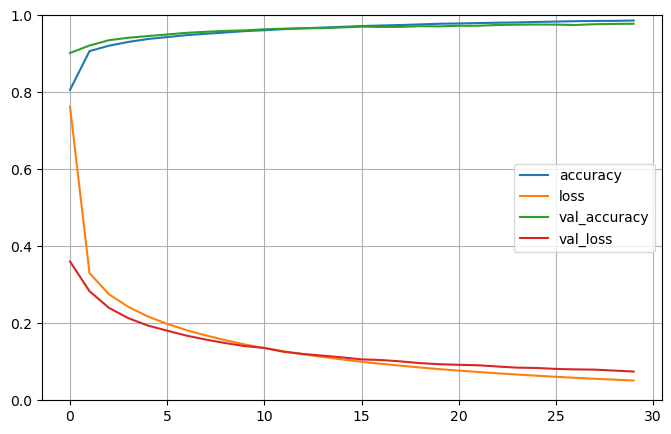

In [28]:
#History contiene los parámetros de entrenamiento, la lista de épocas, y la pérdida y la precisión en cada época en los conjuntos de entrenamiento y validación.
#Podemos visualizar las curvas de aprendizaje:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) #eje y entre 0 y 1
plt.show()

In [6]:
#Evaluamos en el test set (para estimar error de generalización):
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Precisión en test: {test_acc:.4f}")

#Muy buena precisión en el conjunto de prueba --> es un buen modelo

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - accuracy: 0.9754 - loss: 0.0791
Precisión en test: 0.9754


In [7]:
import numpy as np
#Tomamos las primeras 5 imágenes del conjunto de test
X_nuevas = X_test[:5]
y_reales = y_test[:5]

#El modelo predice las probabilidades para cada clase (0-9)
y_predicciones_prop = model.predict(X_nuevas)

# Elegimos la clase con la probabilidad más alta usando argmax
y_predicciones_clase = np.argmax(y_predicciones_prop, axis=1)
print("\n--- Comparación de resultados individuales ---")
for i in range(5):
    print(f"Entrada (Imagen {i}): Predicción -> {y_predicciones_clase[i]} | Valor Real -> {y_reales[i]}")

#Clasifica las 5 correctamente


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

--- Comparación de resultados individuales ---
Entrada (Imagen 0): Predicción -> 7 | Valor Real -> 7
Entrada (Imagen 1): Predicción -> 2 | Valor Real -> 2
Entrada (Imagen 2): Predicción -> 1 | Valor Real -> 1
Entrada (Imagen 3): Predicción -> 0 | Valor Real -> 0
Entrada (Imagen 4): Predicción -> 4 | Valor Real -> 4
